/tmp/ipykernel_343/1661780550.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("unique_id", group_keys=False).apply(make_hourly).reset_index(drop=True)


                    cutoff            mlp
metric                                   
mae    2008-06-15 23:00:00  216342.547245
mape   2008-06-15 23:00:00       0.131673
rmse   2008-06-15 23:00:00  261571.261541
smape  2008-06-15 23:00:00       0.061528

===== BASELINE  =====
X_train: (38904, 6) y_train: (38904,)
X_val: (168, 6) y_val: (168,)
Total grid combinations: 48

===== GRID RUN 1/48 =====
{'layers': 2, 'units': 64, 'optimizer': 'adam', 'lr': 0.001, 'dropout1': 0.05, 'dropout2': 0.02, 'batch_size': 64, 'epochs': 100}
val_mae=152946.015625, val_rmse=191726.359375, val_mape=0.101520, val_smape=0.047718

===== GRID RUN 2/48 =====
{'layers': 2, 'units': 64, 'optimizer': 'adam', 'lr': 0.001, 'dropout1': 0.05, 'dropout2': 0.05, 'batch_size': 64, 'epochs': 100}
val_mae=209758.859375, val_rmse=278840.312500, val_mape=0.131005, val_smape=0.069275

===== GRID RUN 3/48 =====
{'layers': 2, 'units': 64, 'optimizer': 'adam', 'lr': 0.001, 'dropout1': 0.1, 'dropout2': 0.02, 'batch_size': 64, 'epo

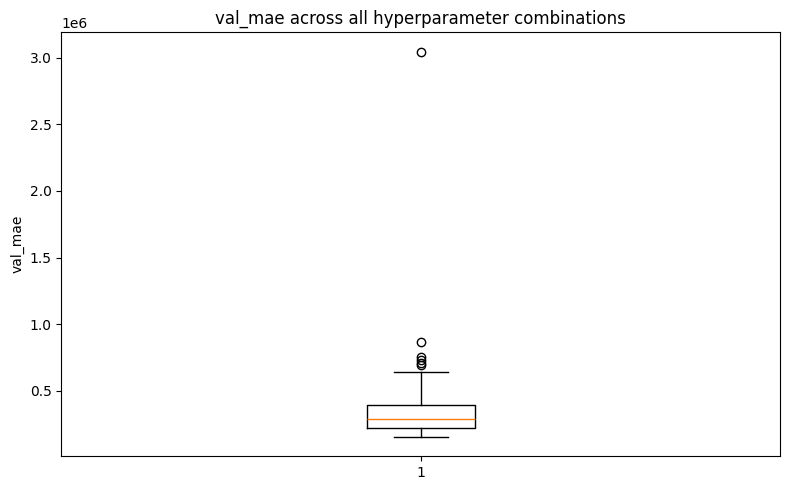

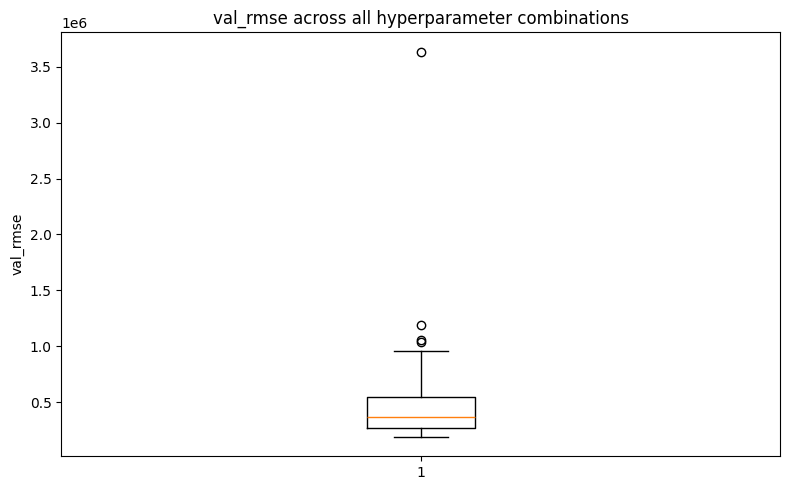

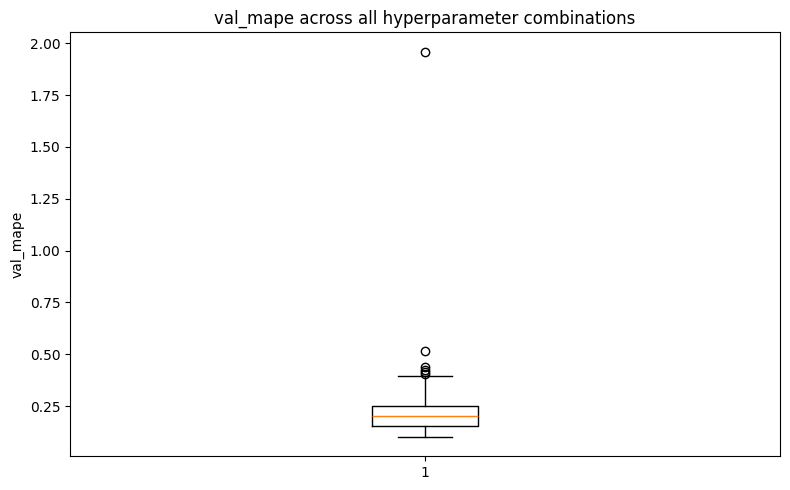

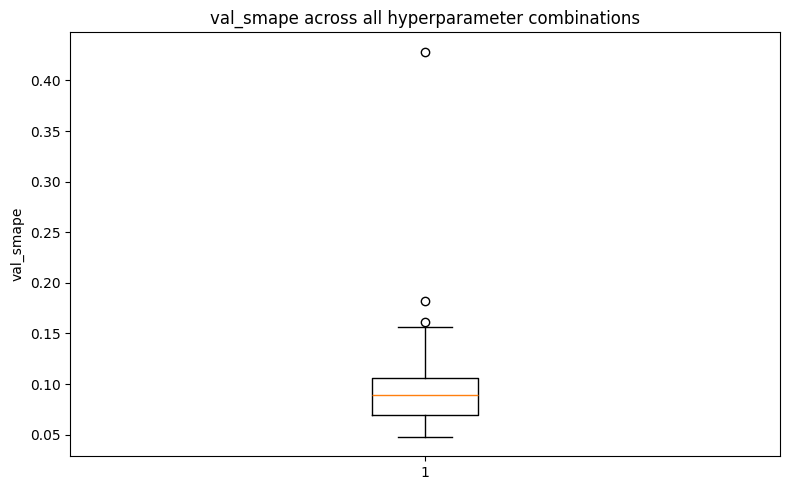

Forecasted 24/168 hours
Forecasted 48/168 hours
Forecasted 72/168 hours
Forecasted 96/168 hours
Forecasted 120/168 hours
Forecasted 144/168 hours
Forecasted 168/168 hours

===== BASELINE TEST SET =====
                  mlp
metric               
mae     474681.750870
rmse    529904.363646
mape         0.240512
smape        0.139582

===== CUSTOM MLP TEST SET =====
                  mlp
metric               
mae     319164.906994
rmse    392587.226402
mape         0.150031
smape        0.083240

===== BEST HYPERPARAMETERS =====
{'layers': 2, 'units': 64, 'optimizer': 'rmsprop', 'lr': 0.001, 'dropout1': 0.05, 'dropout2': 0.05, 'batch_size': 64, 'epochs': 100}


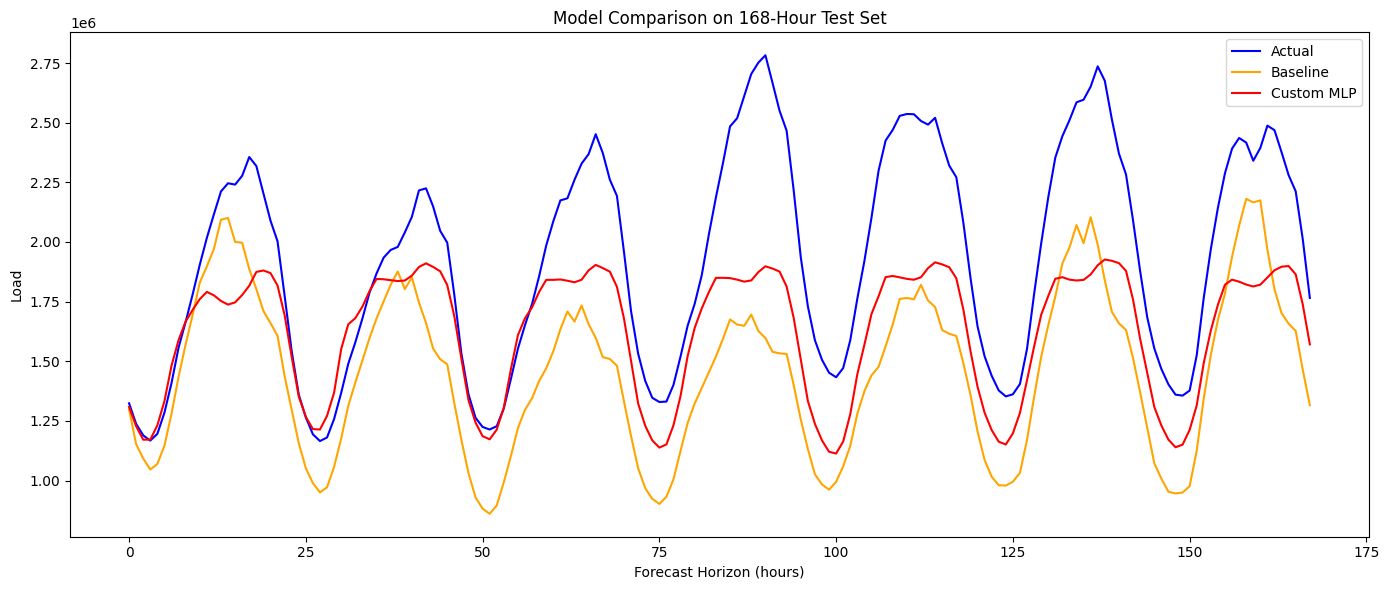

In [2]:
# ==============================
# INSTALL (run once)
# ==============================
!pip install utilsforecast mlforecast #install only once

# ==============================
# IMPORTS
# ==============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from itertools import product

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from sklearn.neural_network import MLPRegressor

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


from utilsforecast.losses import mae, rmse, mape, smape
from utilsforecast.evaluation import evaluate
import seaborn as sns

pd.plotting.register_matplotlib_converters()
plt.rc("figure", figsize=(12, 6))
plt.rc("font", size=10)
os.makedirs("figs", exist_ok=True)

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("load.csv", parse_dates=["timestamp"])
df.columns = ["ds", "y"]
df.insert(0, "unique_id", "Load_hourly")
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# ==============================
# CLEAN DATA (PROF STYLE)
# ==============================
df = df.groupby(["unique_id", "ds"], as_index=False).agg({"y": "mean"})

def make_hourly(g):
    uid = g.name
    g = g.sort_values("ds").set_index("ds")[["y"]]
    idx = pd.date_range(g.index.min(), g.index.max(), freq="h")
    g = g.reindex(idx)
    g["y"] = g["y"].interpolate(limit_direction="both").ffill().bfill()
    g["unique_id"] = uid
    return g.reset_index().rename(columns={"index": "ds"})

df = df.groupby("unique_id", group_keys=False).apply(make_hourly).reset_index(drop=True)

# ==============================
# SPLIT (PROF STYLE)
# ==============================
horizon = 24 * 7
threshold_time = df["ds"].max() - pd.Timedelta(hours=horizon)
df_train = df[df["ds"] <= threshold_time].copy()
df_test = df[df["ds"] > threshold_time].copy()

# ==============================
# BASELINE (EXACT PROF FLOW)
# ==============================
models = {"mlp": MLPRegressor()}

mlf = MLForecast(
    models=models,
    freq="h",
    target_transforms=[Differences([24, 24 * 7])],
    lags=[1, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)],
    },
    date_features=["month", "hour", "dayofweek"],
)

crossvalidation_df = mlf.cross_validation(
    df=df_train,
    h=24 * 7,
    n_windows=1,
    refit=False,
)

metrics = [mae, rmse, mape, smape]

def evaluate_crossvalidation(crossvalidation_df, metrics, models):
    evaluations = []
    for c in crossvalidation_df["cutoff"].unique():
        df_cv = crossvalidation_df.query("cutoff == @c")
        evaluation = evaluate(
            df=df_cv,
            metrics=metrics,
            models=list(models.keys())
        )
        evaluations.append(evaluation)
    evaluations = pd.concat(evaluations, ignore_index=True).drop(columns="unique_id")
    evaluations = evaluations.groupby("metric").mean()
    print(evaluations)
    return evaluations.style.background_gradient(cmap='RdYlGn_r', axis=1)


baseline_eval = evaluate_crossvalidation(crossvalidation_df, metrics, models)
print("\n===== BASELINE  =====")
print(baseline_eval)

mlf_holdout = MLForecast(
    models={"mlp": MLPRegressor()},
    freq="h",
    target_transforms=[Differences([24, 24 * 7])],
    lags=[1, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)],
    },
    date_features=["month", "hour", "dayofweek"],
)
mlf_holdout.fit(df_train)
baseline_preds = mlf_holdout.predict(h=horizon)

# ==============================
# SET SEED (ONLY AFTER BASELINE)
# ==============================
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ==============================
# CUSTOM FEATURE ENGINEERING
# ==============================
def create_supervised_features(train_df):
    feat = train_df.copy()
    feat["hour"] = feat["ds"].dt.hour
    feat["dayofweek"] = feat["ds"].dt.dayofweek
    feat["month"] = feat["ds"].dt.month

    feat["lag1"] = feat["y"].shift(1)
    feat["lag24"] = feat["y"].shift(24)
    feat["lag168"] = feat["y"].shift(168)

    return feat.dropna().reset_index(drop=True)

train_feat = create_supervised_features(df_train)

feature_cols = ["lag1", "lag24", "lag168", "hour", "dayofweek", "month"]

X_all = train_feat[feature_cols].values.astype(np.float32)
y_all = train_feat["y"].values.astype(np.float32)

val_size = 168
X_train_raw = X_all[:-val_size]
y_train_raw = y_all[:-val_size]
X_val_raw = X_all[-val_size:]
y_val_raw = y_all[-val_size:]

mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0) + 1e-8

X_train = (X_train_raw - mean) / std
X_val = (X_val_raw - mean) / std

# optional target scaling for stability
y_mean = y_train_raw.mean()
y_std = y_train_raw.std() + 1e-8
y_train = (y_train_raw - y_mean) / y_std
y_val = (y_val_raw - y_mean) / y_std

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

# ==============================
# CUSTOM MLP + SYSTEMATIC GRID SEARCH
# ==============================
def build_model(input_dim, layers=2, units=64, optimizer_name="adam", lr=3e-4,
                dropout1=0.05, dropout2=0.02):
    inputs = Input(shape=(input_dim,), name="input_features")

    x = Dense(units, activation="relu", kernel_regularizer=l2(1e-5), name="dense_1")(inputs)
    x = BatchNormalization(name="bn_1")(x)
    x = Dropout(dropout1, name="dropout_1")(x)

    if layers == 2:
        x = Dense(units // 2, activation="relu", kernel_regularizer=l2(1e-5), name="dense_2")(x)
        x = BatchNormalization(name="bn_2")(x)
        x = Dropout(dropout2, name="dropout_2")(x)

    x = Dense(32, activation="relu", kernel_regularizer=l2(1e-5), name="dense_3")(x)
    outputs = Dense(1, activation="linear", name="forecast")(x)

    model = Model(inputs=inputs, outputs=outputs, name="custom_mlp_functional")

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model

layers_list = [2]  # fixed to 2 layers, as best configurations show 2 layers work well
units_list = [64, 128]  # test standard (64) and wider (128) for slightly better capacity
optimizer_list = ["adam", "rmsprop"]  # explore both strong default (adam) and alternative (rmsprop) gradient handling
lr_list = [1e-3, 3e-4, 1e-4]  # covers aggressive, medium, and cautious learning rates
dropout1_list = [0.05, 0.10]  # first layer: light and medium
dropout2_list = [0.02, 0.05]  # second layer: light and medium
batch_size_list = [64]  # fixed as it’s stable for MLP on tabular time series
epochs_list = [100]  # only one epoch setting, early stopping still active

#  for TEST ONLY
# layers_list = [2]  #Explore model capacity; 1 layer tests simplicity, 2 layers allow capturing weekly/daily patterns without overfitting
# units_list = [64]  # #2 Not varied in final grid; we fixed Layer1=64, Layer2=32 to keep grid manageable while capturing temporal patterns
# optimizer_list = ["adam"]  #  Adaptive optimizers; Adam for strong default convergence, RMSprop to compare gradient handling for time-series
# lr_list = [0.001]  # #4: Range covers aggressive, medium, and cautious learning rates for stable convergence
# dropout1_list = [0.10]  # #5: Light regularization on first layer to prevent overfitting while preserving peak load information
# dropout2_list = [0.05]  # #6: Light regularization on second layer to reduce overfitting in deeper layer
# batch_size_list = [64]  # #7: Middle value chosen; balances training stability and speed; batch size has minor effect for MLP on tabular time series
# epochs_list = [100] #no need to try more as we have the early stopping criterion.



param_grid = list(product(
    layers_list,
    units_list,
    optimizer_list,
    lr_list,
    dropout1_list,
    dropout2_list,
    batch_size_list,
    epochs_list
))

print(f"Total grid combinations: {len(param_grid)}")

# ===== INIT BEST TRACKING (RMSE ONLY) =====
results = []
best_val_mae = np.inf
best_val_rmse = np.inf
best_val_mape = np.inf
best_val_smape = np.inf
best_model = None
best_history = None
best_params = None


# ===== GRID LOOP =====
# validation timestamps for the last 168 hours inside train_feat
val_timestamps = train_feat["ds"].iloc[-val_size:].reset_index(drop=True)
val_true = y_val_raw.copy()

for i, (layers, units, optimizer_name, lr, dropout1, dropout2, batch_size, epochs_max) in enumerate(param_grid, start=1):
    print(f"\n===== GRID RUN {i}/{len(param_grid)} =====")
    print({
        "layers": layers,
        "units": units,
        "optimizer": optimizer_name,
        "lr": lr,
        "dropout1": dropout1,
        "dropout2": dropout2,
        "batch_size": batch_size,
        "epochs": epochs_max,
    })

    tf.keras.backend.clear_session()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)

    model = build_model(
        input_dim=X_train.shape[1],
        layers=layers,
        units=units,
        optimizer_name=optimizer_name,
        lr=lr,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs_max,
        batch_size=batch_size,
        shuffle=False,
        verbose=0,
        callbacks=callbacks,
    )

    # ===== VALIDATION METRICS USING RECURSIVE 168-STEP FORECAST =====
    history_vals_val = list(df_train["y"].iloc[:-val_size].values.astype(np.float32))
    val_forecasts = []

    for ts in val_timestamps:
        x_next = np.array([
            history_vals_val[-1],
            history_vals_val[-24],
            history_vals_val[-168],
            pd.Timestamp(ts).hour,
            pd.Timestamp(ts).dayofweek,
            pd.Timestamp(ts).month
        ], dtype=np.float32)

        x_next = (x_next - mean) / std
        pred_scaled = float(model.predict(x_next.reshape(1, -1), verbose=0).ravel()[0])
        pred = pred_scaled * y_std + y_mean

        val_forecasts.append(pred)
        history_vals_val.append(pred)

    val_pred = np.array(val_forecasts, dtype=np.float32)
    epochs_ran = len(history.history["loss"])

    val_eval_df = pd.DataFrame({
        "unique_id": ["Load_hourly"] * len(val_true),
        "ds": val_timestamps.values,
        "y": val_true,
        "mlp": val_pred
    })

    val_eval = evaluate(
        df=val_eval_df,
        metrics=metrics,
        models=["mlp"]
    ).drop(columns="unique_id").set_index("metric")

    run_val_mae = float(val_eval.loc["mae", "mlp"])
    run_val_rmse = float(val_eval.loc["rmse", "mlp"])
    run_val_mape = float(val_eval.loc["mape", "mlp"])
    run_val_smape = float(val_eval.loc["smape", "mlp"])

    # ===== STORE RESULTS =====
    results.append({
        "layers": layers,
        "units": units,
        "optimizer": optimizer_name,
        "lr": lr,
        "dropout1": dropout1,
        "dropout2": dropout2,
        "batch_size": batch_size,
        "epochs_max": epochs_max,
        "val_mae": run_val_mae,
        "val_rmse": run_val_rmse,
        "val_mape": run_val_mape,
        "val_smape": run_val_smape,
        "epochs_ran": epochs_ran,
    })

    print(
        f"val_mae={run_val_mae:.6f}, "
        f"val_rmse={run_val_rmse:.6f}, "
        f"val_mape={run_val_mape:.6f}, "
        f"val_smape={run_val_smape:.6f}"
    )

    # ===== BEST CONDITION: RMSE ONLY =====
    if run_val_rmse < best_val_rmse:
        best_val_mae = run_val_mae
        best_val_rmse = run_val_rmse
        best_val_mape = run_val_mape
        best_val_smape = run_val_smape
        best_model = model
        best_history = history.history
        best_params = {
            "layers": layers,
            "units": units,
            "optimizer": optimizer_name,
            "lr": lr,
            "dropout1": dropout1,
            "dropout2": dropout2,
            "batch_size": batch_size,
            "epochs": epochs_max,
        }

# ===== FINAL TABLE =====
results_df = pd.DataFrame(results).sort_values(
    ["val_rmse"]
).reset_index(drop=True)

print("\n===== GRID SEARCH RESULTS (ALL COMBINATIONS) =====")
print(results_df.to_string(index=False))

results_plot_df = pd.DataFrame(results).copy()

# clean inf/nan for plotting
results_plot_df = results_plot_df.replace([np.inf, -np.inf], np.nan)

metric_names = ["val_mae", "val_rmse", "val_mape", "val_smape"]

for metric in metric_names:
    plt.figure(figsize=(8, 5))
    plt.boxplot(results_plot_df[metric].dropna())
    plt.title(f"{metric} across all hyperparameter combinations")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ==============================
# FORECAST (CUSTOM)
# ==============================
def compute_feature_row(history_values, timestamp):
    row = np.array([
        history_values[-1],
        history_values[-24],
        history_values[-168],
        timestamp.hour,
        timestamp.dayofweek,
        timestamp.month
    ], dtype=np.float32)

    row = (row - mean) / std
    return row.reshape(1, -1)

history_vals = list(df_train["y"].values.astype(np.float32))
custom_forecasts = []

for i, ts in enumerate(df_test["ds"], start=1):
    x_next = compute_feature_row(history_vals, pd.Timestamp(ts))
    pred_scaled = float(best_model.predict(x_next, verbose=0).ravel()[0])
    pred = pred_scaled * y_std + y_mean

    custom_forecasts.append(pred)
    history_vals.append(pred)

    if i % 24 == 0 or i == len(df_test):
        print(f"Forecasted {i}/{len(df_test)} hours")

# ==============================
# FINAL PLOT
# ==============================
y_true = df_test["y"].values
y_baseline = baseline_preds["mlp"].values
y_custom = np.array(custom_forecasts)

baseline_test_df = pd.DataFrame({
    "unique_id": df_test["unique_id"].values,
    "ds": df_test["ds"].values,
    "y": y_true,
    "mlp": y_baseline
})

custom_test_df = pd.DataFrame({
    "unique_id": df_test["unique_id"].values,
    "ds": df_test["ds"].values,
    "y": y_true,
    "mlp": y_custom
})

baseline_test_eval = evaluate(
    df=baseline_test_df,
    metrics=metrics,
    models=["mlp"]
).drop(columns="unique_id").set_index("metric")

custom_test_eval = evaluate(
    df=custom_test_df,
    metrics=metrics,
    models=["mlp"]
).drop(columns="unique_id").set_index("metric")

print("\n===== BASELINE TEST SET =====")
print(baseline_test_eval)

print("\n===== CUSTOM MLP TEST SET =====")
print(custom_test_eval)

baseline_mae = float(baseline_test_eval.loc["mae", "mlp"])
baseline_rmse = float(baseline_test_eval.loc["rmse", "mlp"])
baseline_mape = float(baseline_test_eval.loc["mape", "mlp"])
baseline_smape = float(baseline_test_eval.loc["smape", "mlp"])

custom_mae = float(custom_test_eval.loc["mae", "mlp"])
custom_rmse = float(custom_test_eval.loc["rmse", "mlp"])
custom_mape = float(custom_test_eval.loc["mape", "mlp"])
custom_smape = float(custom_test_eval.loc["smape", "mlp"])

if (
    custom_mae < baseline_mae and
    custom_rmse < baseline_rmse and
    custom_mape < baseline_mape and
    custom_smape < baseline_smape
):
    print("\n===== BEST HYPERPARAMETERS =====")
    print(best_params)
    # print("Best validation MAE  :", best_val_mae)
    # print("Best validation RMSE :", best_val_rmse)
    # print("Best validation MAPE :", best_val_mape)
    # print("Best validation SMAPE:", best_val_smape)

    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label="Actual", color="blue")
    plt.plot(y_baseline, label="Baseline", color="orange")
    plt.plot(y_custom, label="Custom MLP", color="red")
    plt.title("Model Comparison on 168-Hour Test Set")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("Load")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nCustom MLP did NOT beat baseline on all 4 metrics, so no best hyperparameters are printed and no plot is shown.")
